# Μέρος 3: Συνένωση Εικόνων (Image Stitching) για Δημιουργία Πανοράματος

# Βήμα 0: Διάβασμα εικόνων

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Load first 2 images
image1 = cv2.imread('part3_data/img1a_ratio05.jpg')
image2 = cv2.imread('part3_data/img1b_ratio05.jpg')


## Βήμα 1: Εντοπισμός χαρακτηριστικών ενδιαφέροντος και εξαγωγή περιγραφητών

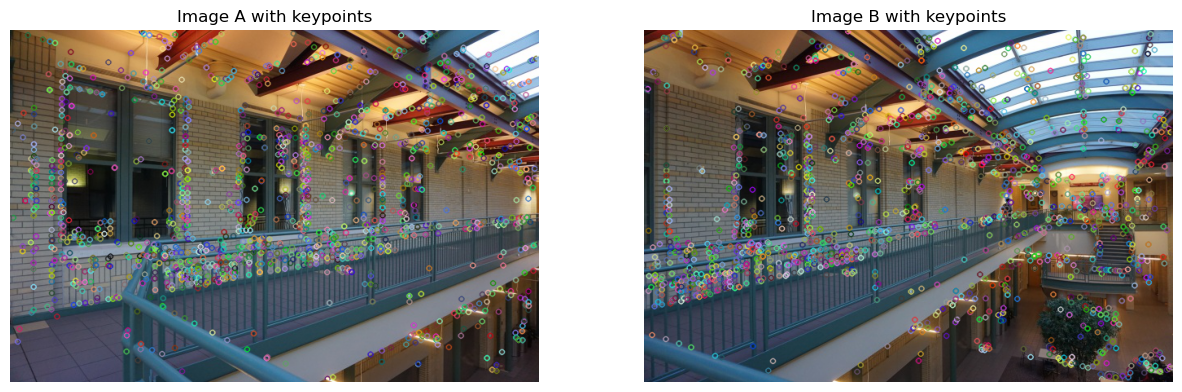

In [5]:
# Detect SIFT keypoints and descriptors in the images
sift = cv2.xfeatures2d.SIFT_create()

keypoints1, descriptors1 = sift.detectAndCompute(image1, None)
image1_keypoints = cv2.drawKeypoints(image1, keypoints1, None)
keypoints2, descriptors2 = sift.detectAndCompute(image2, None)
image2_keypoints = cv2.drawKeypoints(image2, keypoints2, None)

# Display results
image1_keypoints = cv2.cvtColor(image1_keypoints, cv2.COLOR_BGR2RGB)
image2_keypoints = cv2.cvtColor(image2_keypoints, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.subplot(121), plt.imshow(image1_keypoints)
plt.title('Image A with keypoints'), plt.axis('off')
plt.subplot(122), plt.imshow(image2_keypoints)
plt.title('Image B with keypoints'), plt.axis('off')
plt.show()

## Βήμα 2: Διαδικασία ταιριάσματος χαρακτηριστικών μεταξύ δύο εικόνων

In [7]:
# Find 2 matches for each keaypoint of image 1
FL1NN_INDEX_KDTREE = 0
index_params = dict(algorithm = FL1NN_INDEX_KDTREE, trees = 5)
search_params = {}

flann = cv2.FlannBasedMatcher(index_params,search_params)

matches = flann.knnMatch(descriptors1, descriptors2, k=2)

## Βήμα 3: Διατήρηση μόνο των πιο έγκυρων αντιστοιχίσεων μέσω εφαρμογής του κριτηρίου Lowe

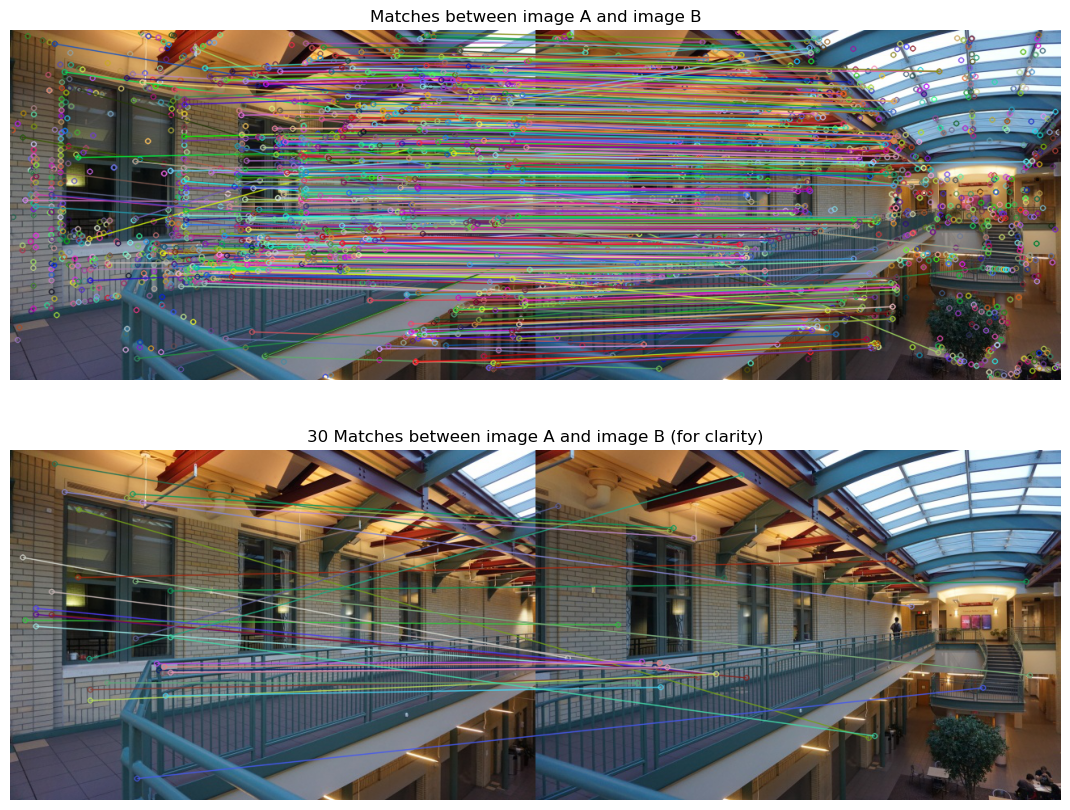

In [10]:
# Apply Lowe's ratio test
good_matches = []
for m, n in matches:
    if m.distance / n.distance < 0.8:
        good_matches.append(m)

# Draw matches
image_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches, None)
image_matches = cv2.cvtColor(image_matches, cv2.COLOR_BGR2RGB)
clean_matches = cv2.drawMatches(image1, keypoints1, image2, keypoints2, good_matches[:30], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
clean_matches = cv2.cvtColor(clean_matches, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.subplot(2,1,1)
plt.imshow(image_matches)
plt.axis('off')
plt.title('Matches between image A and image B')
plt.subplot(2,1,2)
plt.imshow(clean_matches)
plt.axis('off')
plt.title('30 Matches between image A and image B (for clarity)')
plt.show()

# Βήμα 4: Υπολογισμός ομογραφίας με RANSAC

In [12]:
# For each keypoint match, get the coordinates of the keypoint
srcPoints = [keypoints1[m.queryIdx].pt for m in good_matches]
srcPoints = np.array(srcPoints).reshape(-1, 1, 2)
dstPoints = [keypoints2[m.trainIdx].pt for m in good_matches]
dstPoints = np.array(dstPoints).reshape(-1, 1, 2)

# Find homography
threshold = 3.0 # between 1.0 and 10.0
H, mask = cv2.findHomography(srcPoints, dstPoints, cv2.RANSAC, threshold)

## Βήμα 5: Υπολογισμός μετασχηματισμένης εικόνας μέσω εφαρμογής Inverse warping

In [ ]:
def projectionImage(H, image):
    
    return image_warped, topleft_coords

img1_warped, topleft_coords = projectionImage(H, image1)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 650 is different from 3)

## Βήμα 6: Συνένωση των εικόνων